#  School Data : EDA (Exploratory Data Analysis)


## Step 0 : Import Libraries
> Libraries are like toolboxes. We import them once at the start.

In [1]:
import pandas as pd          # pandas = for reading and working with tables (like Excel)
import matplotlib.pyplot as plt  # matplotlib = for making graphs/charts
import seaborn as sns         # seaborn = makes nicer-looking graphs (built on matplotlib)
import numpy as np            # numpy = for math operations
import warnings               # warnings = to hide annoying warning messages

warnings.filterwarnings('ignore')   # hide all warnings so output stays clean
sns.set_style('whitegrid')          # set a clean white background for all plots

print('All libraries loaded!')

All libraries loaded!


---
## Step 1 : Load and Understand the Data
> First, we load the Excel file and check what's inside.

In [2]:
# Read the Excel file and store it in a variable called 'df'
# 'df' stands for DataFrame — think of it as a table in Python
df = pd.read_excel('School data.xlsx')

# Show how many rows and columns the data has
print('Total Rows    :', df.shape[0])   # shape[0] = number of rows
print('Total Columns :', df.shape[1])   # shape[1] = number of columns

Total Rows    : 5200
Total Columns : 17


In [3]:
# Show the first 5 rows of the data
# This helps us see what the data looks like
df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [4]:
# Show column names, data types, and how many values are non-empty
# This tells us which columns have missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          4940 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             4940 non-null   float64
 12  Functional_Toilets             5200 non-null   i

In [5]:
# Show basic statistics for all number columns
# min, max, mean, etc. — gives a quick overview
df.describe().round(2)   # round(2) = show only 2 decimal places

,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
count,4942.00,5200.00,5200.00,4940.00,5200.00,5200.00,5200.00,4940.00,5200.00,5200.00,5200.00,5200.00,4941.00
mean,60.06,62.97,61.34,29.98,8.10,2.00,0.90,0.30,0.95,0.48,30.40,16.77,49.78
std,15.11,16.57,18.03,9.96,3.92,1.43,0.31,0.46,0.21,0.50,11.92,12.77,16.94
min,0.33,1.38,1.51,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-5.00
25%,49.58,51.52,48.89,23.10,5.40,1.00,1.00,0.00,1.00,0.00,22.30,6.20,38.40
50%,59.85,63.03,61.15,29.80,8.00,2.00,1.00,0.00,1.00,0.00,31.00,15.20,49.50
75%,70.63,74.45,73.95,36.60,10.80,3.00,1.00,1.00,1.00,1.00,38.80,25.30,60.80
max,107.34,100.00,100.00,100.00,22.70,9.00,1.00,1.00,1.00,1.00,73.10,66.00,150.00


###  What we see:
- **5200 schools** and **17 columns**
- Columns include: scores, teacher info, infrastructure (electricity, internet, toilets, library)
- Some score values are above 100 or negative — these are **data errors** we need to fix
- **Target variable** (what we want to predict): `%_Math_Score` / `%_Language_Score` / `%_Science_Score`

---
## Step 2 : Data Cleaning
> Real data is messy. We fix missing values, wrong values, and duplicates.

In [6]:
# Check how many values are missing in each column
# isnull() marks empty cells as True
# sum() counts how many True values exist per column
df.isnull().sum()

School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64

In [7]:
# Fill missing values with the MEDIAN of each column
# Median = the middle value when sorted
# We use median (not mean/average) because it is not affected by extreme values

cols_with_missing = ['%_Math_Score', 'Teacher_Student_Ratio',
                     'Internet_Available', 'Parent_Literacy_Rate']

for col in cols_with_missing:                      # loop through each column
    median_value = df[col].median()                # find the median
    df[col].fillna(median_value, inplace=True)     # fill empty cells with median

print('Missing values after filling:')
print(df.isnull().sum())   # should show 0 for all columns now

Missing values after filling:
School_ID                        0
District                         0
Block                            0
Urban_Rural                      0
%_Math_Score                     0
%_Language_Score                 0
%_Science_Score                  0
Teacher_Student_Ratio            0
Avg_Teacher_Experience_Years     0
Teacher_Trainings_Attended       0
Electricity_Available            0
Internet_Available               0
Functional_Toilets               0
Library_Available                0
%_Marginalized_Students          0
%_Students_With_Home_Internet    0
Parent_Literacy_Rate             0
dtype: int64


In [8]:
# Check for duplicate rows (same school entered twice)
# duplicated() returns True for rows that are exact copies
print('Duplicate rows:', df.duplicated().sum())   # should be 0

Duplicate rows: 0


In [9]:
# Fix values that are outside the valid range
# Scores should be between 0 and 100 — anything else is a data error
# clip(0, 100) cuts off anything below 0 or above 100

df['%_Math_Score']     = df['%_Math_Score'].clip(0, 100)
df['%_Language_Score'] = df['%_Language_Score'].clip(0, 100)
df['%_Science_Score']  = df['%_Science_Score'].clip(0, 100)
df['Parent_Literacy_Rate'] = df['Parent_Literacy_Rate'].clip(0, 100)

print('Out-of-range values fixed!')
print('Max Math Score now:', df['%_Math_Score'].max())   # should be ≤ 100

Out-of-range values fixed!
Max Math Score now: 100.0


---
## Step 3 : EDA (Exploratory Data Analysis)
### 3a. Univariate Analysis
> Uni = one. We look at **one column at a time** to understand its distribution.

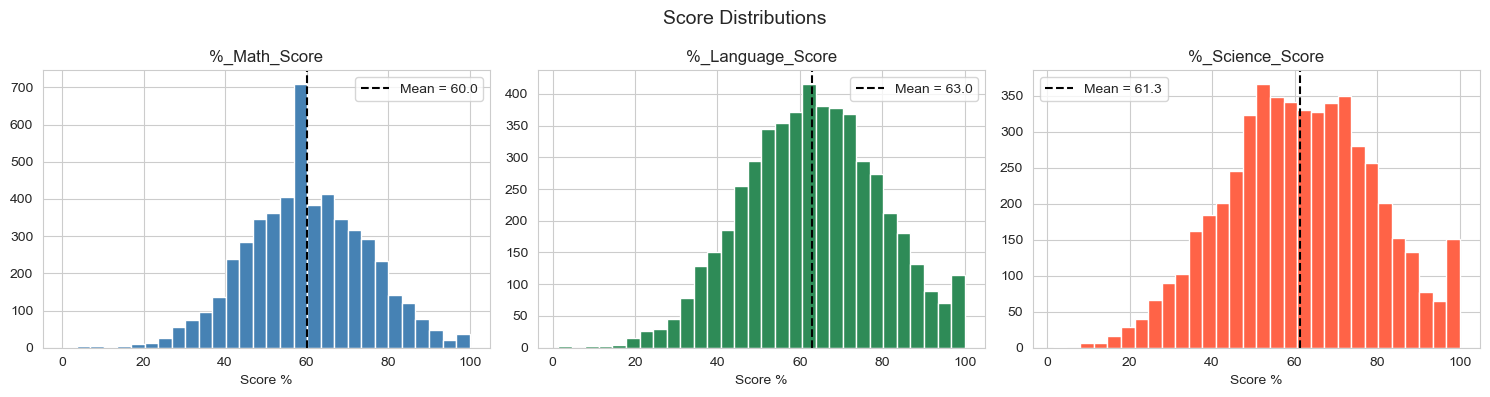

In [10]:
# Plot histograms for Math, Language and Science scores
# A histogram shows how many schools fall in each score range

fig, axes = plt.subplots(1, 3, figsize=(15, 4))   # create 3 side-by-side charts

score_cols = ['%_Math_Score', '%_Language_Score', '%_Science_Score']
colors     = ['steelblue', 'seagreen', 'tomato']

for ax, col, color in zip(axes, score_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')  # draw bars
    ax.axvline(df[col].mean(), color='black', linestyle='--',  # draw mean line
               label=f"Mean = {df[col].mean():.1f}")
    ax.set_title(col)          # title of each chart
    ax.set_xlabel('Score %')   # x-axis label
    ax.legend()                # show legend

plt.suptitle('Score Distributions', fontsize=14)
plt.tight_layout()   # auto-adjust spacing so charts don't overlap
plt.show()

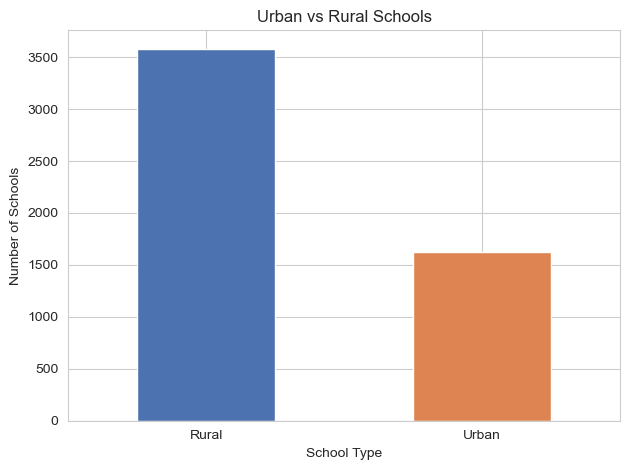

In [12]:
# Bar chart: How many Urban vs Rural schools?
# value_counts() counts how many times each category appears

df['Urban_Rural'].value_counts().plot(
    kind='bar',
    color=['#4C72B0', '#DD8452'],
    edgecolor='white'
)
plt.title('Urban vs Rural Schools')   # chart title
plt.xlabel('School Type')             # x-axis label
plt.ylabel('Number of Schools')       # y-axis label
plt.xticks(rotation=0)                # keep labels horizontal
plt.tight_layout()
plt.show()

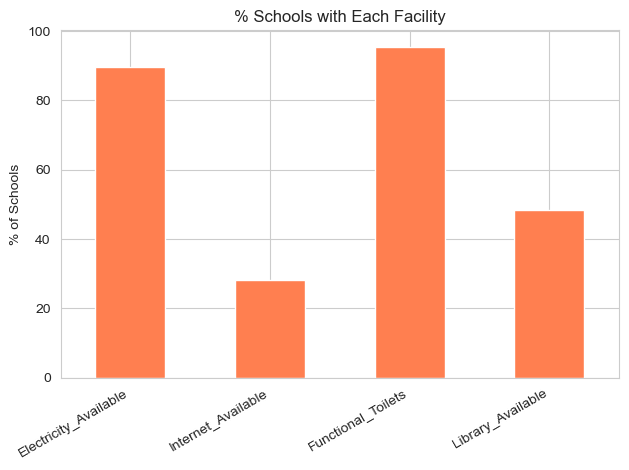

In [13]:
# Bar chart: What % of schools have each infrastructure facility?
# For binary columns (0 = No, 1 = Yes), mean() gives % of schools with 'Yes'

infra_cols = ['Electricity_Available', 'Internet_Available',
              'Functional_Toilets', 'Library_Available']

# Calculate % of schools that have each facility
infra_pct = df[infra_cols].mean().clip(0, 1) * 100   # multiply by 100 to get %

infra_pct.plot(kind='bar', color='coral', edgecolor='white')
plt.title('% Schools with Each Facility')
plt.ylabel('% of Schools')
plt.xticks(rotation=30, ha='right')   # tilt labels so they don't overlap
plt.tight_layout()
plt.show()

### 3b. Bivariate Analysis
> Bi = two. We compare **two columns** to find relationships.

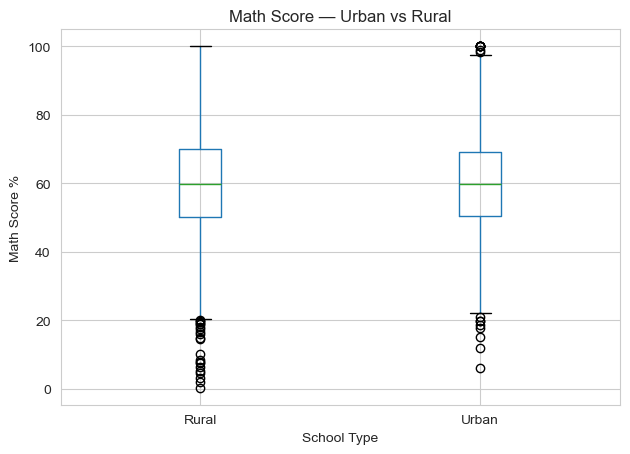

In [14]:
# Boxplot: Compare Math scores for Urban vs Rural schools
# A boxplot shows the spread and median of a group
# The box = middle 50% of values. Line inside = median.

df.boxplot(column='%_Math_Score', by='Urban_Rural')
plt.title('Math Score — Urban vs Rural')   # our custom title
plt.suptitle('')    # remove the extra default title pandas adds
plt.xlabel('School Type')
plt.ylabel('Math Score %')
plt.tight_layout()
plt.show()

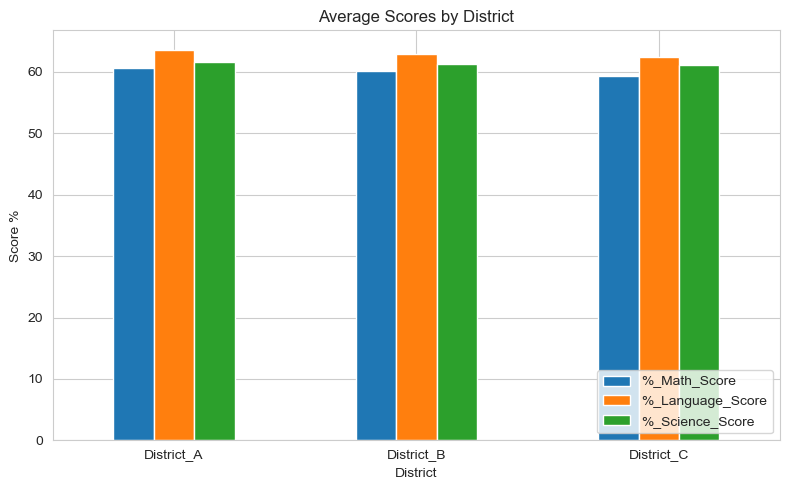

In [15]:
# Bar chart: Average scores in each District
# groupby('District') = group all schools by their district
# .mean() = calculate average for each group

district_avg = df.groupby('District')[['%_Math_Score',
                                        '%_Language_Score',
                                        '%_Science_Score']].mean()

district_avg.plot(kind='bar', figsize=(8, 5))
plt.title('Average Scores by District')
plt.ylabel('Score %')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

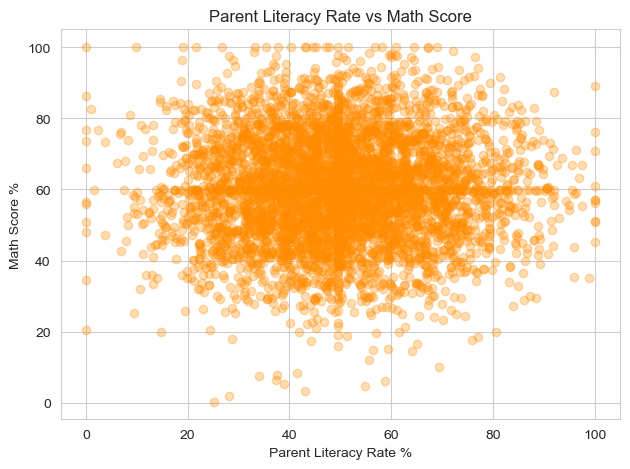

In [13]:
# Scatter plot: Does Parent Literacy affect Math Score?
# Each dot = one school
# If dots go up-right → positive relationship

plt.scatter(
    df['Parent_Literacy_Rate'],   # x-axis
    df['%_Math_Score'],           # y-axis
    alpha=0.3,                    # alpha = transparency (so overlapping dots are visible)
    color='darkorange'
)
plt.title('Parent Literacy Rate vs Math Score')
plt.xlabel('Parent Literacy Rate %')
plt.ylabel('Math Score %')
plt.tight_layout()
plt.show()

### 3c. Correlation Analysis
> Correlation tells us how strongly two columns are related.
> **+1 = perfectly related, 0 = no relation, -1 = opposite relation**

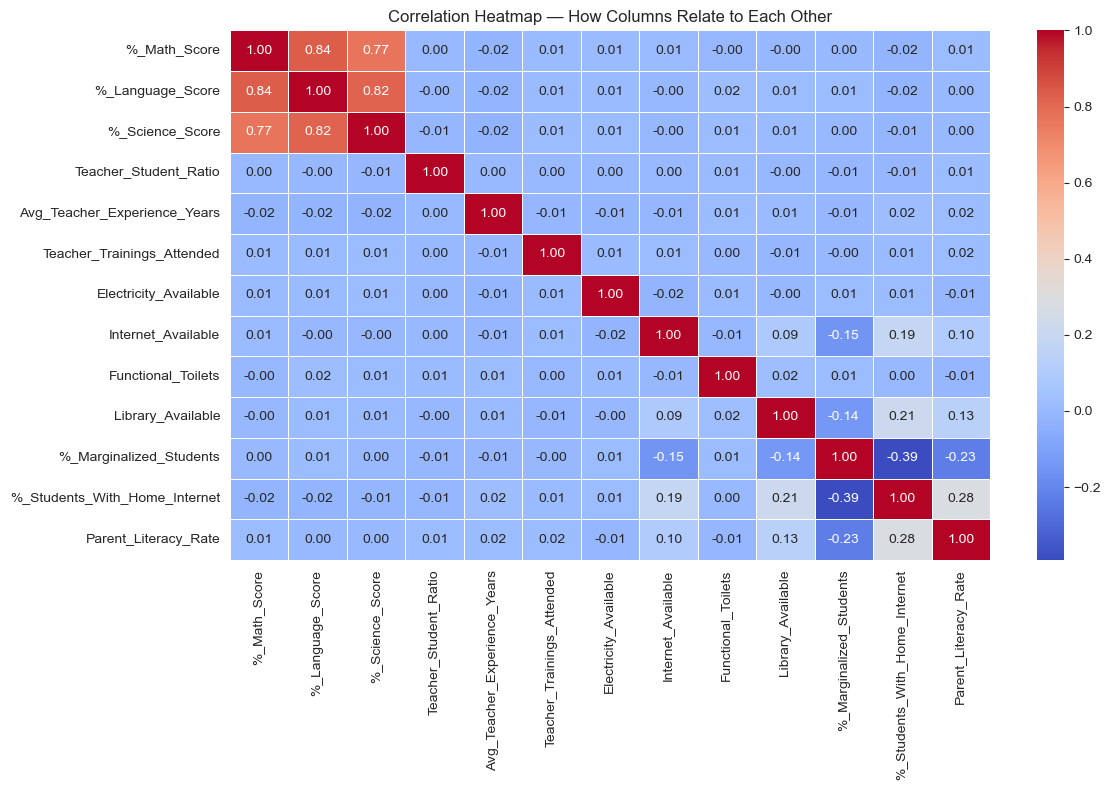

In [17]:
# Select only number columns (can't correlate text)
num_df = df.select_dtypes(include='number')

# Calculate correlation between every pair of columns
corr = num_df.corr()

# Draw a heatmap — color shows strength of correlation
# Red = strong positive, Blue = strong negative, White = no relation
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,        # show numbers inside each box
    fmt='.2f',         # round to 2 decimal places
    cmap='coolwarm',   # red-white-blue color scheme
    linewidths=0.5     # thin lines between boxes
)
plt.title('Correlation Heatmap — How Columns Relate to Each Other')
plt.tight_layout()
plt.show()

In [18]:
# Show which columns are most correlated with Math Score
# Sorted from strongest to weakest relationship

math_corr = corr['%_Math_Score'].drop('%_Math_Score')   # remove self-correlation
math_corr_sorted = math_corr.sort_values(ascending=False)

print('Correlation with Math Score (highest to lowest):')
print(math_corr_sorted.round(3))

Correlation with Math Score (highest to lowest):
%_Language_Score                 0.836
%_Science_Score                  0.770
Parent_Literacy_Rate             0.011
Electricity_Available            0.010
Internet_Available               0.009
Teacher_Trainings_Attended       0.007
%_Marginalized_Students          0.005
Teacher_Student_Ratio            0.003
Library_Available               -0.003
Functional_Toilets              -0.004
Avg_Teacher_Experience_Years    -0.018
%_Students_With_Home_Internet   -0.021
Name: %_Math_Score, dtype: float64


---
## Step 4 : Key Insights
> These are the important things we learned from the graphs and numbers.

1.  **Urban schools score higher** - Urban schools consistently have better Math, Language & Science scores than Rural ones.

2.  **Parent literacy = better student scores** - Where parents are more educated, students perform better. Home environment matters.

3.  **Poor infrastructure = poor scores** - Schools without electricity, internet, or libraries score lower. Resources matter.

4.  **All 3 subjects move together** - A school good in Math is also good in Language & Science. School quality drives everything.

5.  **Marginalized students are at a disadvantage** -Higher % of marginalized students = lower average scores. This shows an equity problem.

6.  **Teacher experience alone isn't enough** - Experience has a weak effect. Training + infrastructure matters more.

---
## Step 5 : Feature Engineering + Simple ML Model
> We create new useful columns, then build a model to **predict school performance**.

In [14]:
# FEATURE ENGINEERING - creating new columns from existing ones

# 1. Average score = mean of all 3 subject scores
#    This becomes our TARGET — what we want to predict
df['Avg_Score'] = (df['%_Math_Score'] +
                   df['%_Language_Score'] +
                   df['%_Science_Score']) / 3

# 2. Infrastructure score = total facilities available (0 to 4)
#    clip(0,1) makes sure values are only 0 or 1 before adding
df['Infra_Score'] = (df['Electricity_Available'].clip(0,1) +
                     df['Internet_Available'].clip(0,1) +
                     df['Functional_Toilets'].clip(0,1) +
                     df['Library_Available'].clip(0,1))

# 3. Is_Urban = 1 if Urban, 0 if Rural
#    ML models need numbers, not text
df['Is_Urban'] = (df['Urban_Rural'] == 'Urban').astype(int)

print('New columns added!')
df[['Avg_Score', 'Infra_Score', 'Is_Urban']].head()

New columns added!


,Avg_Score,Infra_Score,Is_Urban
0,47.026667,2.0,0
1,82.806667,1.0,0
2,43.750000,2.0,0
3,42.610000,2.0,1
4,48.780000,2.0,0


In [16]:
from sklearn.linear_model import LinearRegression    # the model we'll use
from sklearn.model_selection import train_test_split  # to split data into train/test
from sklearn.metrics import r2_score, mean_absolute_error  # to measure accuracy

# Choose which columns to use as INPUT (features)
features = [
    'Avg_Teacher_Experience_Years',    # how experienced are teachers
    'Teacher_Trainings_Attended',      # how many trainings they attended
    'Parent_Literacy_Rate',            # parent education level
    'Infra_Score',                     # our new infrastructure column
    'Is_Urban',                        # our new urban/rural column
    '%_Marginalized_Students',         # % of disadvantaged students
    '%_Students_With_Home_Internet'    # % students with internet at home
]

X = df[features]      # X = input columns (what we feed the model)
y = df['Avg_Score']   # y = output column (what we want to predict)

# Split data: 80% for training the model, 20% for testing it
# random_state=42 means the split is always the same (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows :', len(X_train))
print('Testing rows  :', len(X_test))

Training rows : 4160
Testing rows  : 1040


In [17]:
# Create the model
model = LinearRegression()

# Train the model on training data
# 'fit' = teach the model to find patterns
model.fit(X_train, y_train)

# Use the trained model to predict scores on TEST data (data it hasn't seen)
y_pred = model.predict(X_test)

# Measure how good our predictions are
# R² score: 1.0 = perfect, 0.0 = useless
# MAE: average error in score points (lower = better)
print('R² Score (accuracy) :', round(r2_score(y_test, y_pred), 3))
print('MAE (avg error pts) :', round(mean_absolute_error(y_test, y_pred), 2))

R² Score (accuracy) : -0.0
MAE (avg error pts) : 12.62


In [18]:
# Show which feature affects the prediction the most
# Coefficient = how much the score changes when that feature increases by 1

import pandas as pd
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model.coef_
})

# Sort by absolute value — biggest impact first
coef_df['Impact'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Impact', ascending=False)

print('Feature importance (biggest impact first):')
coef_df[['Feature', 'Coefficient']]

Feature importance (biggest impact first):


,Feature,Coefficient
3,Infra_Score,0.391811
0,Avg_Teacher_Experience_Years,-0.088931
4,Is_Urban,0.052692
1,Teacher_Trainings_Attended,0.043517
6,%_Students_With_Home_Internet,-0.033576
2,Parent_Literacy_Rate,0.007006
5,%_Marginalized_Students,0.005169


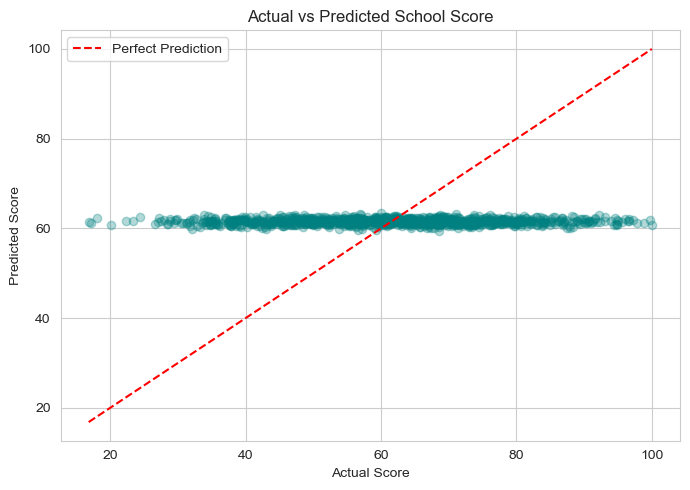

In [23]:
# Final chart: Actual scores vs Predicted scores
# If model is good, dots should be close to the red diagonal line

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')   # each dot = one school

# Draw a perfect prediction line (if prediction = actual)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Score')      # x = what the score really was
plt.ylabel('Predicted Score')   # y = what our model guessed
plt.title('Actual vs Predicted School Score')
plt.legend()
plt.tight_layout()
plt.show()

---
##  Summary

| Step | What We Did |
|------|-------------|
| 1 | Loaded the data - 5200 schools, 17 columns |
| 2 | Cleaned data - filled missing values with median, fixed wrong values |
| 3a | Univariate - histograms of scores, urban/rural counts, infra availability |
| 3b | Bivariate - compared urban vs rural, district-wise scores, parent literacy effect |
| 3c | Correlation - heatmap showing which columns affect each other |
| 4 | Wrote 6 key insights from the graphs |
| 5 | Built a Linear Regression model to predict school performance |

**Tools used:** Python, pandas, matplotlib, seaborn, scikit-learn